All libraries imported successfully!

FIRST 5 ROWS:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

LAST 5 ROWS:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   

/tmp/ipykernel_2489/2367980418.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


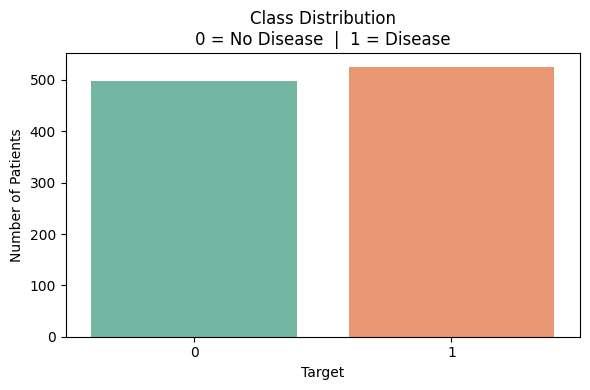

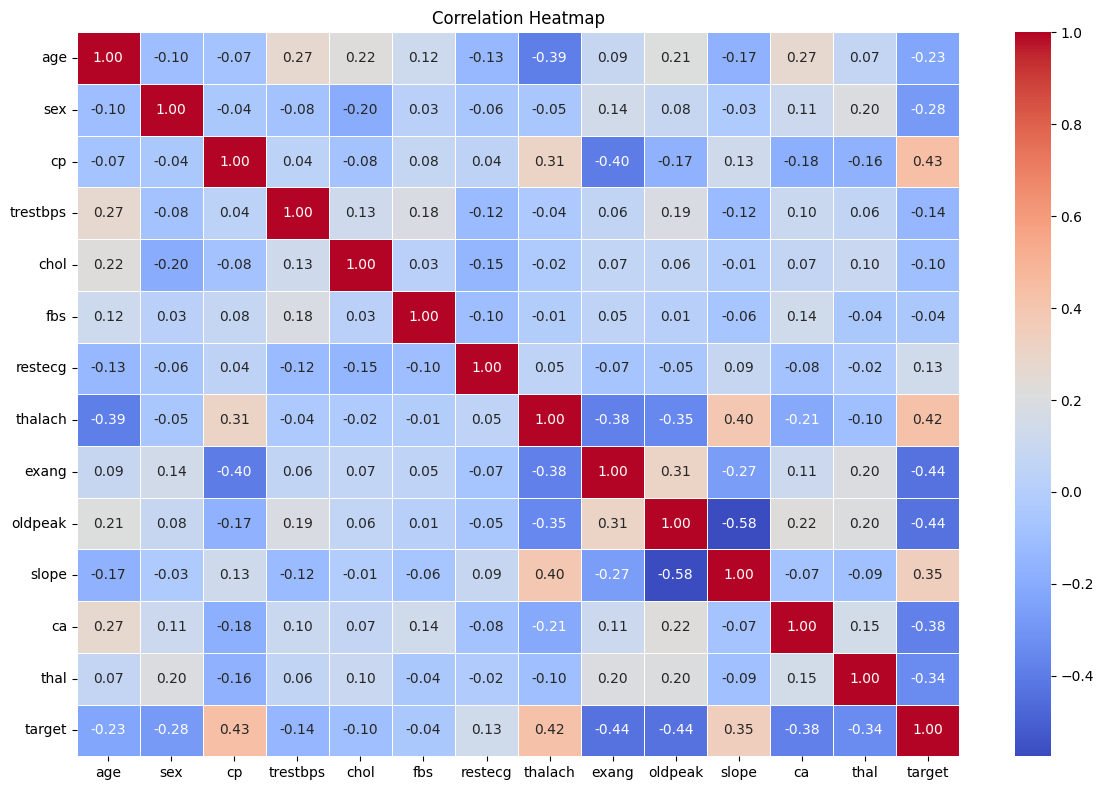

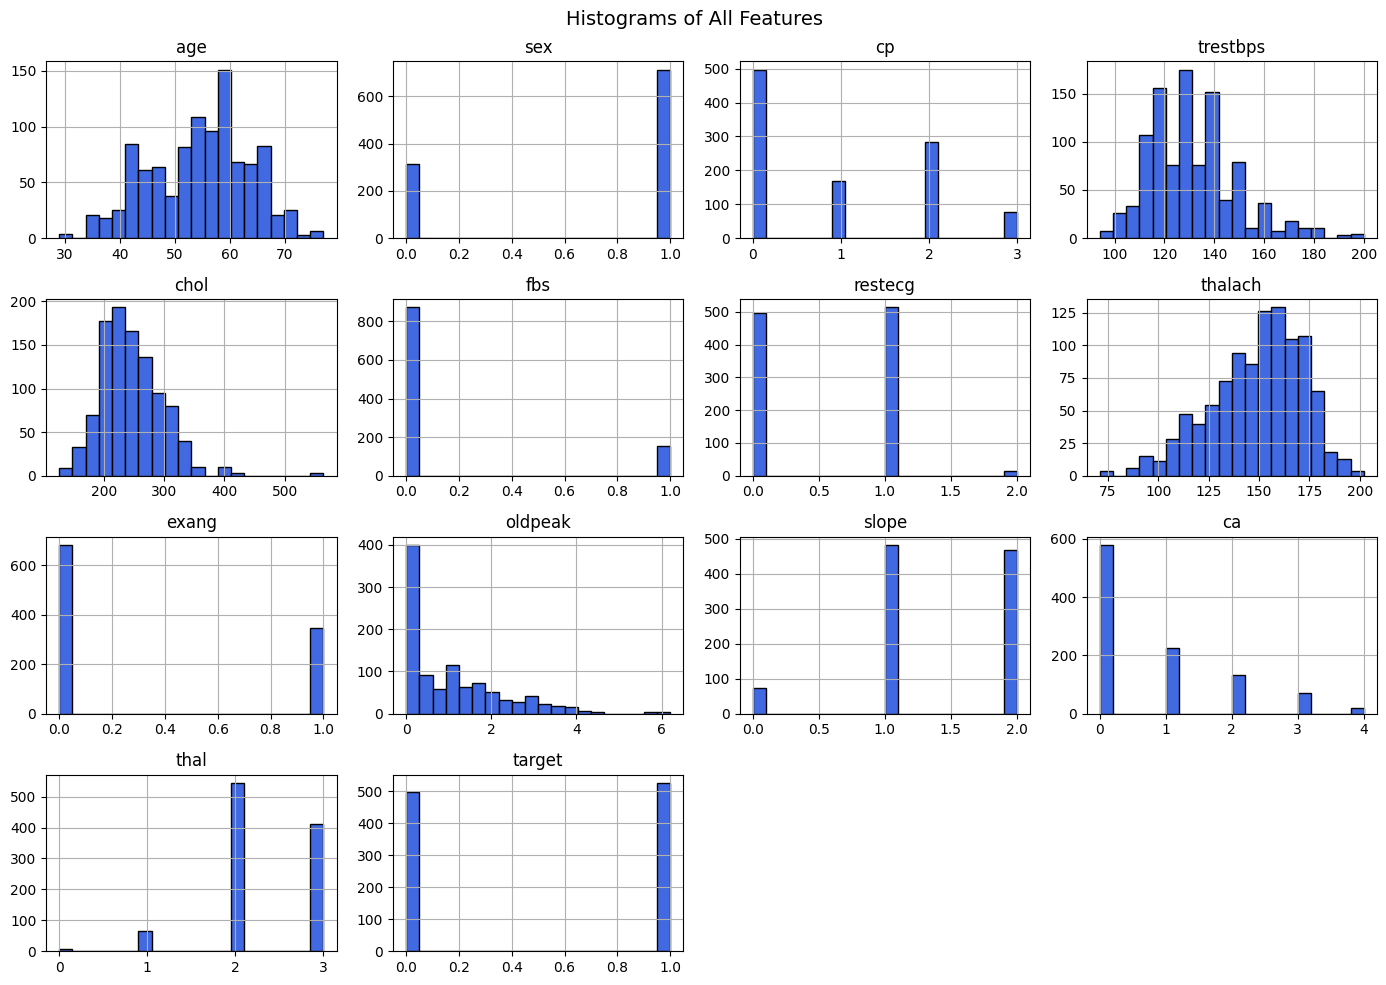

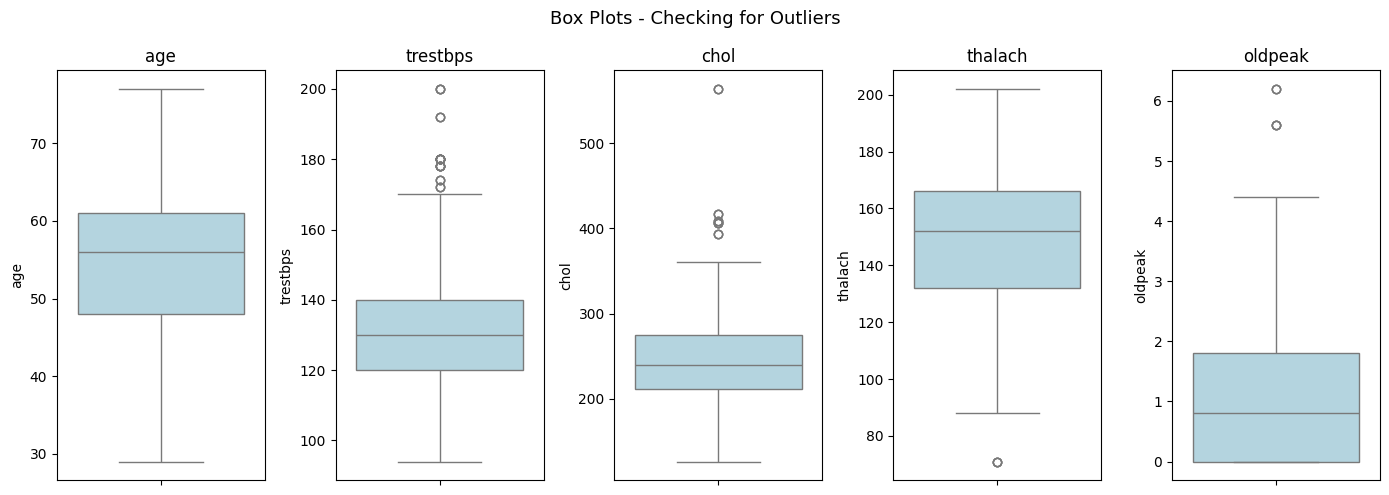

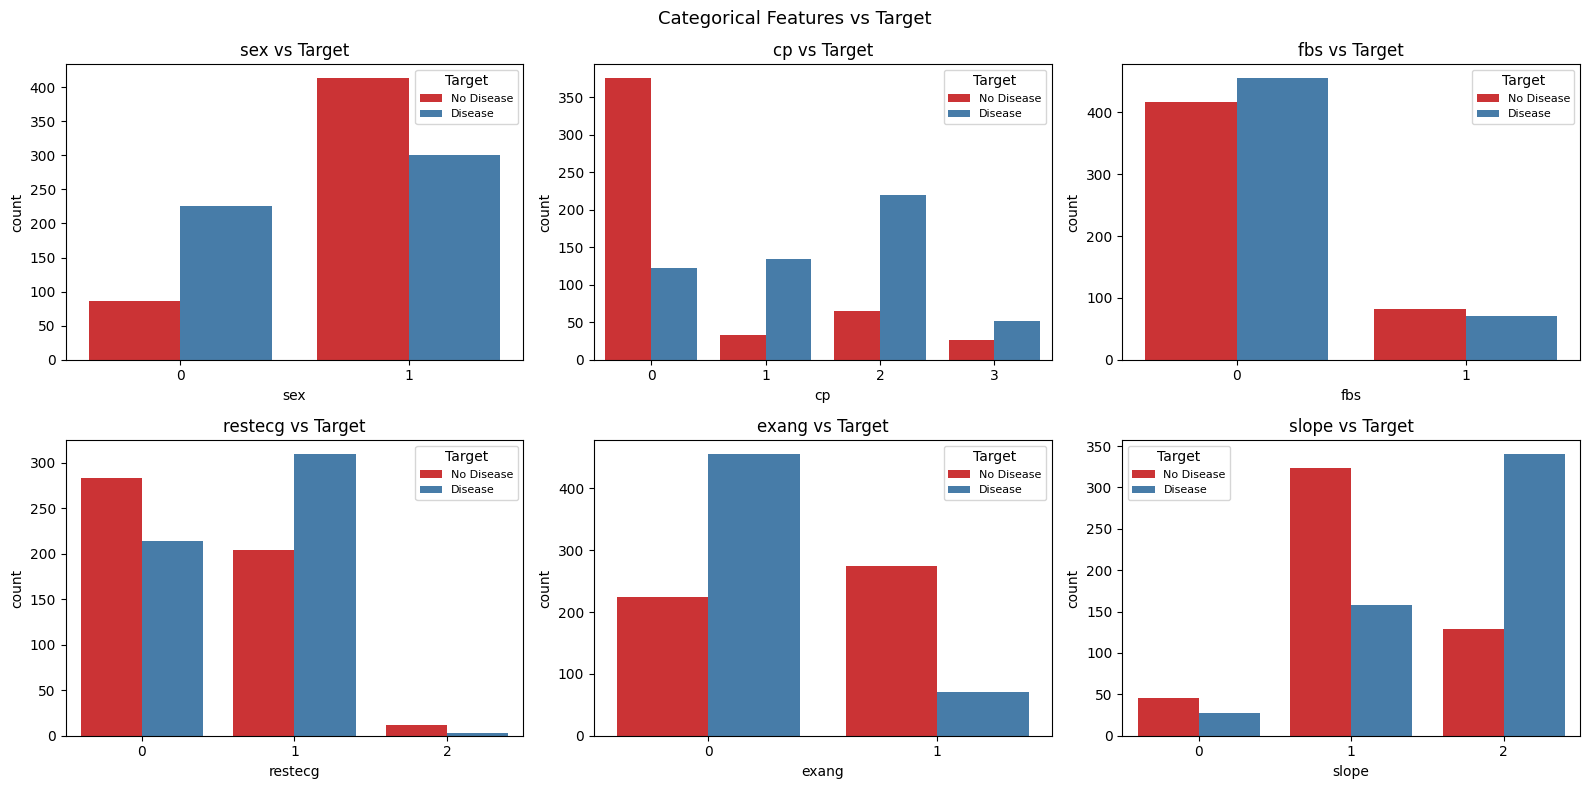

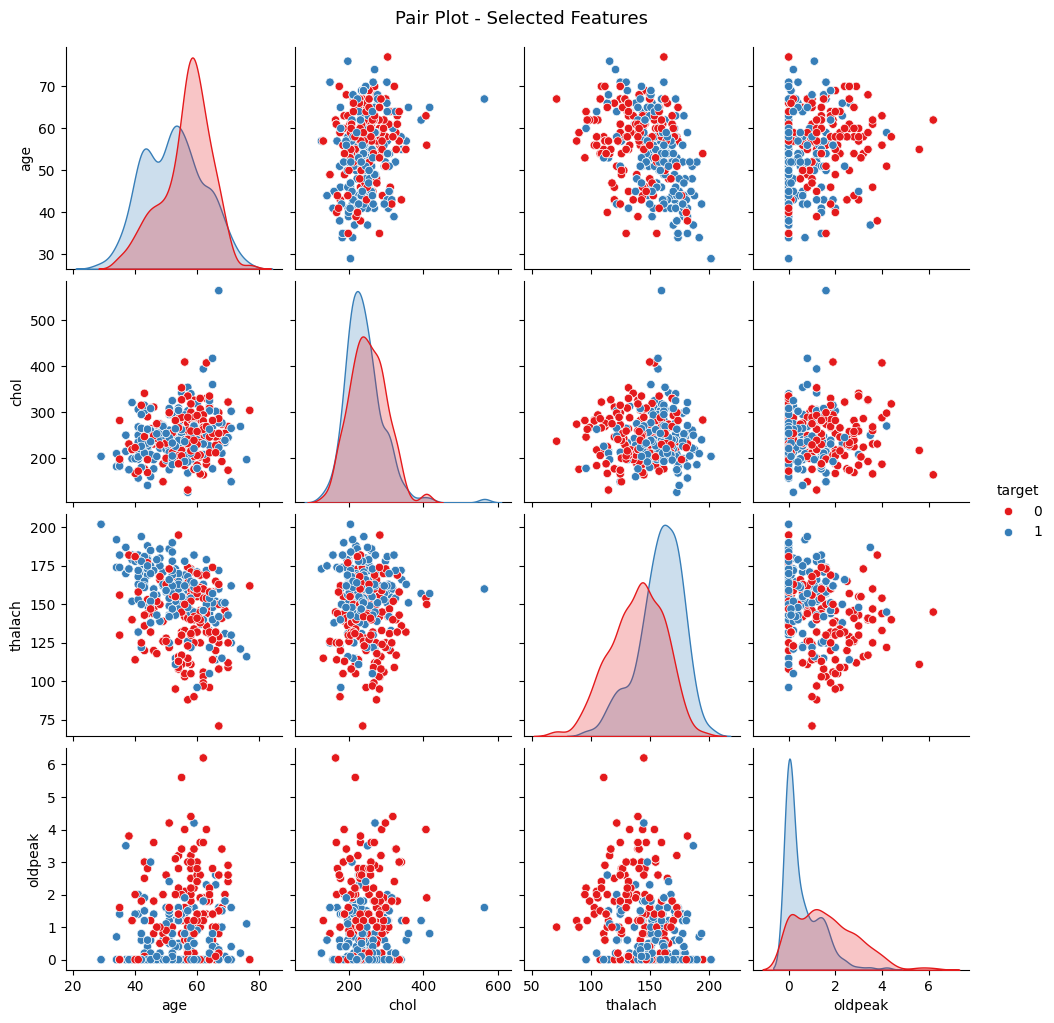


Duplicate rows removed: 723
Dataset size after cleaning: (302, 14)
No missing values found. Dataset is clean!

--- PREPROCESSING ---
All features are numeric. No encoding needed.
No StandardScaler required for Naive Bayes.
Dataset is ready for modeling!

--- FEATURE SELECTION ---
Input Features (X): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target Column (y)  : 'target'
Target Values      : 0 = No Heart Disease, 1 = Heart Disease
X shape: (302, 13)
y shape: (302,)

--- TRAIN-TEST SPLIT ---
X_train: (241, 13) -> 80% data used to train
X_test : (61, 13) -> 20% data used to test
y_train: (241,)
y_test : (61,)

Naive Bayes algorithm ready. See code comments for full explanation.

Model training complete!
The model has learned patterns from the training data.

--- PREDICTIONS ON TEST DATA (First 10 Samples) ---
Predicted: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int6

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


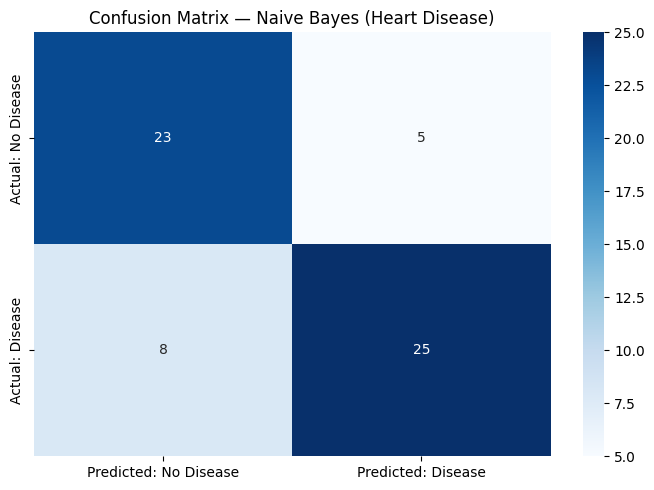


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  No Disease       0.74      0.82      0.78        28
     Disease       0.83      0.76      0.79        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61


--- CLASS PROBABILITIES (First 5 Test Samples) ---
The model picks the class with the HIGHER probability.

Sample 1: P(No Disease)=0.9832  P(Disease)=0.0168  -> Predicted: No Disease
Sample 2: P(No Disease)=0.0535  P(Disease)=0.9465  -> Predicted: Disease
Sample 3: P(No Disease)=1.0000  P(Disease)=0.0000  -> Predicted: No Disease
Sample 4: P(No Disease)=0.1998  P(Disease)=0.8002  -> Predicted: Disease
Sample 5: P(No Disease)=0.0088  P(Disease)=0.9912  -> Predicted: Disease

Learned Prior Probabilities (from training data):
  P(No Disease) = 0.4564
  P(Disease)    = 0.5436

--- FEATURE MEAN VALUES LEARNED BY MODEL ---
 Feature  Mean_N

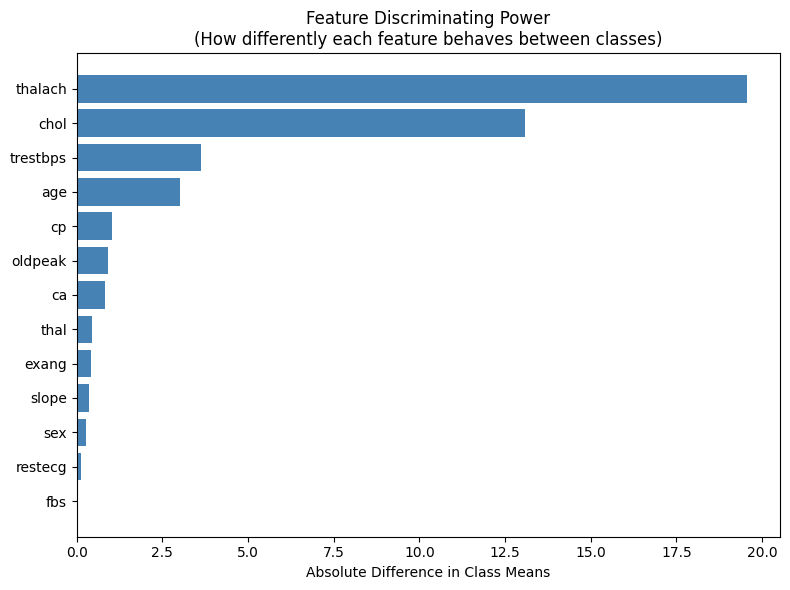


--- DECISION BOUNDARY (2 Features: age vs thalach) ---
Training a separate 2-feature model just for visualization...


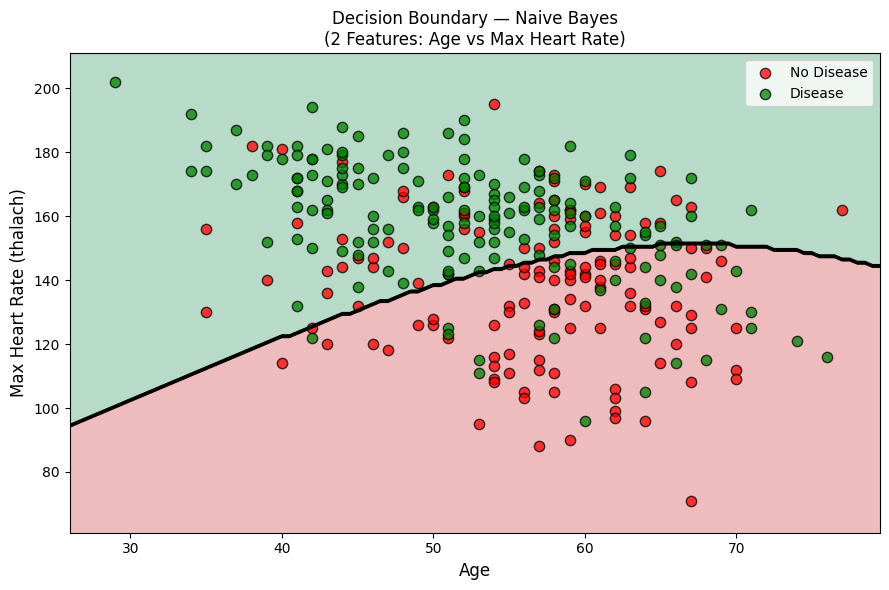

Note: This boundary uses only 2 of 13 features.
The actual trained model uses all 13 features and is more accurate.

                  FINAL MODEL SUMMARY
  Algorithm           : Gaussian Naive Bayes
  Dataset             : Heart Disease (Kaggle)
  Dataset URL         : https://www.kaggle.com/datasets/
                        johnsmith88/heart-disease-dataset
  File Name           : heart.csv
  Number of Samples   : 302
  Number of Features  : 13
  Train / Test Split  : 80% / 20%
  Training Accuracy   : 82.99%
  Testing  Accuracy   : 78.69%
  Precision           : 83.33%
  Recall              : 75.76%
  F1 Score            : 79.37%


In [ ]:
# ==============================================================
# NAIVE BAYES CLASSIFIER - HEART DISEASE PREDICTION
# ==============================================================
#
#  Dataset  : Heart Disease Dataset
#  URL      : https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
#
#  HOW TO USE:
#  1. Open the URL above in your browser
#  2. Click "Download" to get the ZIP file
#  3. Extract it — you will find a file named  heart.csv
#  4. Place  heart.csv  in the SAME folder as this script
#  5. Run this script in VS Code or any Python IDE
#
#  COLUMNS IN heart.csv:
#  age, sex, cp, trestbps, chol, fbs, restecg,
#  thalach, exang, oldpeak, slope, ca, thal, target
#  (target: 0 = No Heart Disease, 1 = Heart Disease)
# ==============================================================


# ==============================================================
# STEP 1: IMPORT LIBRARIES
# ==============================================================

import pandas as pd                # For loading and working with data tables
import numpy as np                 # For numerical operations and arrays
import matplotlib.pyplot as plt    # For creating charts and graphs
import seaborn as sns              # For beautiful statistical visualizations

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics to measure model performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")


# ==============================================================
# STEP 2: LOAD DATASET
# ==============================================================

# Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
# Make sure heart.csv is in the same folder as this script
df = pd.read_csv("Heart-dis.csv")

# Show first 5 rows to understand the data
print("\n" + "=" * 55)
print("FIRST 5 ROWS:")
print(df.head())

# Show last 5 rows
print("\nLAST 5 ROWS:")
print(df.tail())

# Shape tells us how many rows (samples) and columns (features)
print("\nSHAPE (rows, columns):", df.shape)

# Names of all columns
print("\nCOLUMN NAMES:")
print(df.columns.tolist())

# Data type of each column (int, float, object)
print("\nDATA TYPES:")
print(df.dtypes)

# General info: non-null count, memory usage, dtypes
print("\nDATASET INFO:")
df.info()

# Statistical summary: count, mean, std, min, 25%, 50%, 75%, max
print("\nSTATISTICAL SUMMARY:")
print(df.describe())


# ==============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================

# ----- 3.1 Check for Missing Values -----
# Missing values can mislead the model if not handled
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# ----- 3.2 Check for Duplicate Rows -----
# Duplicates can cause the model to overfit on repeated data
print("\n--- DUPLICATE ROWS ---")
print("Total duplicate rows:", df.duplicated().sum())

# ----- 3.3 Class Distribution -----
# Check if the dataset is balanced between the two classes
print("\n--- CLASS DISTRIBUTION ---")
print(df['target'].value_counts())
print("0 = No Heart Disease | 1 = Heart Disease")

# Visualize class counts as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Class Distribution\n0 = No Disease  |  1 = Disease")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# ----- 3.4 Correlation Heatmap -----
# Shows how strongly each pair of features is related
# Values close to 1 or -1 = strong relationship
# Values close to 0 = weak relationship
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ----- 3.5 Histograms -----
# Shows the distribution (spread) of values for each feature
df.hist(figsize=(14, 10), bins=20, color='royalblue', edgecolor='black')
plt.suptitle("Histograms of All Features", fontsize=14)
plt.tight_layout()
plt.show()

# ----- 3.6 Box Plots -----
# Box plots help spot outliers (extreme values) in numerical features
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(14, 5))
for i, col in enumerate(num_features):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.suptitle("Box Plots - Checking for Outliers", fontsize=13)
plt.tight_layout()
plt.show()

# ----- 3.7 Count Plots: Categorical Features vs Target -----
# See how each categorical feature distributes across classes
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
plt.figure(figsize=(16, 8))
for i, col in enumerate(cat_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, hue='target', data=df, palette='Set1')
    plt.title(f'{col} vs Target')
    plt.legend(title='Target', labels=['No Disease', 'Disease'], fontsize=8)
plt.suptitle("Categorical Features vs Target", fontsize=13)
plt.tight_layout()
plt.show()

# ----- 3.8 Pair Plot (Selected Features) -----
# Pair plot shows relationships between every pair of selected features
# Color shows which class each data point belongs to
pair_cols = ['age', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[pair_cols], hue='target', palette='Set1', diag_kind='kde')
plt.suptitle("Pair Plot - Selected Features", y=1.02, fontsize=13)
plt.show()


# ==============================================================
# STEP 4: DATA CLEANING
# ==============================================================

# ----- 4.1 Remove Duplicate Rows -----
# Duplicates make the model "see" the same patient twice, biasing results
rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]
print(f"\nDuplicate rows removed: {rows_before - rows_after}")
print(f"Dataset size after cleaning: {df.shape}")

# ----- 4.2 Handle Missing Values -----
# This dataset is usually clean, but we always check
missing_total = df.isnull().sum().sum()
if missing_total > 0:
    # Fill missing numerical values with the column median
    # We use MEDIAN (not mean) because it is not affected by outliers
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print("Missing values filled with column medians.")
else:
    print("No missing values found. Dataset is clean!")


# ==============================================================
# STEP 5: FEATURE ENGINEERING / PREPROCESSING
# ==============================================================

# WHY NAIVE BAYES DOES NOT NEED FEATURE SCALING:
# ------------------------------------------------
# Gaussian Naive Bayes calculates the PROBABILITY of each feature value
# using the formula for the normal (Gaussian) distribution.
# This formula uses the MEAN and STANDARD DEVIATION of each feature.
#
# Because it works with probabilities (not distances), the SCALE of
# features does NOT affect the result.
#
# Example:
# - Cholesterol (100 to 400) and Age (20 to 80) are on different scales.
# - Naive Bayes handles each feature INDEPENDENTLY using its own mean/std.
# - No need to bring them to the same scale.
#
# Therefore: StandardScaler is NOT needed for Naive Bayes.
#
# All features in this dataset are already numeric integers and floats.
# No Label Encoding or One-Hot Encoding is required.

print("\n--- PREPROCESSING ---")
print("All features are numeric. No encoding needed.")
print("No StandardScaler required for Naive Bayes.")
print("Dataset is ready for modeling!")


# ==============================================================
# STEP 6: FEATURE SELECTION
# ==============================================================

# X = all columns EXCEPT 'target' — these are the INPUT FEATURES
# The model will use these to learn patterns
X = df.drop('target', axis=1)

# y = the 'target' column — this is what we want to PREDICT
y = df['target']

print("\n--- FEATURE SELECTION ---")
print("Input Features (X):", X.columns.tolist())
print("Target Column (y)  : 'target'")
print("Target Values      : 0 = No Heart Disease, 1 = Heart Disease")
print("X shape:", X.shape)
print("y shape:", y.shape)


# ==============================================================
# STEP 7: TRAIN-TEST SPLIT
# ==============================================================

# Split 80% for training, 20% for testing
# random_state=42 ensures the same split every run (reproducible results)
# stratify=y ensures both classes appear in similar proportions in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# X_train : Features used to TRAIN the model
# X_test  : Features used to TEST the trained model (model never saw these)
# y_train : Correct labels for training samples
# y_test  : Correct labels for testing samples (compare with predictions)

print("\n--- TRAIN-TEST SPLIT ---")
print("X_train:", X_train.shape, "-> 80% data used to train")
print("X_test :", X_test.shape,  "-> 20% data used to test")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==============================================================
# STEP 8: ALGORITHM EXPLANATION - NAIVE BAYES
# ==============================================================

# ---------------------------------------------------------------
# WHAT IS NAIVE BAYES?
# ---------------------------------------------------------------
# Naive Bayes is a supervised CLASSIFICATION algorithm.
# It is based on BAYES THEOREM from probability theory.
#
# BAYES THEOREM (in simple language):
# "Given all the features of a patient, what is the probability
#  that they have heart disease?"
#
# The formula:
# P(Disease | Features) = P(Features | Disease) * P(Disease)
#                         ----------------------------------------
#                                    P(Features)
#
# The model calculates this probability for each class (0 and 1),
# then predicts the class with the HIGHEST probability.
#
# WHY IS IT CALLED "NAIVE"?
# It makes a BIG assumption: ALL FEATURES ARE INDEPENDENT.
# This means it assumes that:
#   Age has NOTHING to do with Cholesterol.
#   Cholesterol has NOTHING to do with Blood Pressure.
# This is "naive" because in real life, features DO affect each other.
# But this simplification makes the algorithm very FAST and simple.
#
# INDEPENDENCE ASSUMPTION:
# P(all features) = P(age) * P(chol) * P(thalach) * ... (multiply all)
#
# WHY GAUSSIAN NAIVE BAYES?
# Our features are continuous numbers (age, cholesterol, etc.).
# GaussianNB assumes these follow a normal distribution (bell curve).
# It learns the mean and variance of each feature for each class.
#
# ADVANTAGES:
# + Very fast to train
# + Works well with small datasets
# + No feature scaling required
# + Easy to understand
# ---------------------------------------------------------------

print("\nNaive Bayes algorithm ready. See code comments for full explanation.")


# ==============================================================
# STEP 9: TRAIN THE MODEL
# ==============================================================

# Create a Gaussian Naive Bayes model object
model = GaussianNB()

# Train the model on training data
# During fit(), the model learns:
#   1. Prior probability P(class) for each class
#   2. Mean and Variance of each feature for each class
model.fit(X_train, y_train)

print("\nModel training complete!")
print("The model has learned patterns from the training data.")


# ==============================================================
# STEP 10: PREDICTIONS
# ==============================================================

# Predict class labels for all test samples
y_pred = model.predict(X_test)

# Show first 10 predictions side by side with actual values
print("\n--- PREDICTIONS ON TEST DATA (First 10 Samples) ---")
print("Predicted:", list(y_pred[:10]))
print("Actual:   ", list(y_test.values[:10]))

print("\nSide-by-side comparison:")
for i in range(10):
    pred_label   = "Disease   " if y_pred[i] == 1 else "No Disease"
    actual_label = "Disease   " if y_test.values[i] == 1 else "No Disease"
    correct      = "CORRECT" if y_pred[i] == y_test.values[i] else "WRONG"
    print(f"  Sample {i+1}: Predicted={pred_label} | Actual={actual_label} -> {correct}")

# ----- Predict a custom single patient -----
# Feature order must match training columns:
# age, sex, cp, trestbps, chol, fbs, restecg,
# thalach, exang, oldpeak, slope, ca, thal
custom_patient = [[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]]

custom_pred    = model.predict(custom_patient)
custom_proba   = model.predict_proba(custom_patient)

print("\n--- CUSTOM PATIENT PREDICTION ---")
print("Feature Order: age, sex, cp, trestbps, chol, fbs, restecg,")
print("               thalach, exang, oldpeak, slope, ca, thal")
print("Input Values :", custom_patient[0])
print("Prediction   :", "Heart Disease (1)" if custom_pred[0] == 1 else "No Heart Disease (0)")
print(f"Probability - No Disease : {custom_proba[0][0] * 100:.2f}%")
print(f"Probability - Disease    : {custom_proba[0][1] * 100:.2f}%")


# ==============================================================
# STEP 11: EVALUATION
# ==============================================================

# Calculate all important evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\n--- EVALUATION METRICS ---")
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"            How many predictions were correct overall")
print(f"\nPrecision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"            Of all predicted 'Disease', how many are truly Disease")
print(f"\nRecall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"            Of all actual 'Disease' cases, how many did we detect")
print(f"\nF1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"            Harmonic mean of Precision and Recall (balanced metric)")

# ----- Confusion Matrix -----
cm = confusion_matrix(y_test, y_pred)
print("\n--- CONFUSION MATRIX ---")
print(cm)
print(f"\nTrue Negatives  (TN): {cm[0][0]}  -> Correctly predicted No Disease")
print(f"False Positives (FP): {cm[0][1]}  -> Wrongly predicted Disease (actually No Disease)")
print(f"False Negatives (FN): {cm[1][0]}  -> Wrongly predicted No Disease (actually Disease)")
print(f"True Positives  (TP): {cm[1][1]}  -> Correctly predicted Disease")

# Show confusion matrix as a heatmap for easy reading
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease',    'Actual: Disease'])
plt.title("Confusion Matrix — Naive Bayes (Heart Disease)")
plt.tight_layout()
plt.show()

# Full classification report with per-class metrics
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


# ==============================================================
# STEP 12: FEATURE IMPORTANCE / INTERPRETATION
# ==============================================================

# NOTE: Naive Bayes does NOT support direct feature importance.
# Decision Trees have feature importance; Naive Bayes does NOT.
# There are no weights or coefficients assigned to features.
#
# Instead, we interpret the model using:
#  1. predict_proba() — class probabilities for each prediction
#  2. model.class_prior_ — learned prior probability of each class
#  3. model.theta_ — mean of each feature per class (what was learned)
#
# The absolute difference in mean values between classes tells us
# which features the model "sees" most differently between sick/healthy patients.

# Show class probabilities for the first 5 test samples
proba_test = model.predict_proba(X_test[:5])

print("\n--- CLASS PROBABILITIES (First 5 Test Samples) ---")
print("The model picks the class with the HIGHER probability.\n")
for i in range(5):
    label = "Disease" if y_pred[i] == 1 else "No Disease"
    print(f"Sample {i+1}: P(No Disease)={proba_test[i][0]:.4f}  "
          f"P(Disease)={proba_test[i][1]:.4f}  -> Predicted: {label}")

# Show prior probabilities learned from training data
print(f"\nLearned Prior Probabilities (from training data):")
print(f"  P(No Disease) = {model.class_prior_[0]:.4f}")
print(f"  P(Disease)    = {model.class_prior_[1]:.4f}")

# Show mean of each feature per class (what model learned about each group)
mean_no_disease = model.theta_[0]  # mean values for class 0
mean_disease    = model.theta_[1]  # mean values for class 1
feature_names   = X.columns.tolist()

means_df = pd.DataFrame({
    'Feature'         : feature_names,
    'Mean_No_Disease' : mean_no_disease.round(3),
    'Mean_Disease'    : mean_disease.round(3),
    'Abs_Difference'  : abs(mean_disease - mean_no_disease).round(3)
})
print("\n--- FEATURE MEAN VALUES LEARNED BY MODEL ---")
print(means_df.to_string(index=False))

# Bar chart: which features differ most between classes
means_sorted = means_df.sort_values('Abs_Difference', ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(means_sorted['Feature'], means_sorted['Abs_Difference'], color='steelblue')
plt.xlabel("Absolute Difference in Class Means")
plt.title("Feature Discriminating Power\n(How differently each feature behaves between classes)")
plt.tight_layout()
plt.show()


# ==============================================================
# STEP 13: DECISION BOUNDARY (2 Features)
# ==============================================================

# We cannot draw a decision boundary for 13 features at once.
# To visualize it, we select 2 meaningful features:
#   - 'age'     (patient age)
#   - 'thalach' (maximum heart rate achieved)
# These two features show a clear separation between the two classes.
# NOTE: This 2-feature model is only for VISUALIZATION purposes.
#       The actual model above uses all 13 features.

print("\n--- DECISION BOUNDARY (2 Features: age vs thalach) ---")
print("Training a separate 2-feature model just for visualization...")

# Extract only 2 features for the boundary plot
X_2d = df[['age', 'thalach']].values
y_2d = df['target'].values

# Split this 2-feature data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42
)

# Train a Naive Bayes model on only these 2 features
model_2d = GaussianNB()
model_2d.fit(X_train_2d, y_train_2d)

# Create a grid of points that covers the entire feature space
x_min = X_2d[:, 0].min() - 3
x_max = X_2d[:, 0].max() + 3
y_min = X_2d[:, 1].min() - 10
y_max = X_2d[:, 1].max() + 10

# Mesh grid: a fine grid of (x, y) pairs over the feature space
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 1.0)
)

# Predict the class label for every point in the grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.contour(xx, yy, Z, colors='black', linewidths=0.8)

# Overlay actual data points
for cls, label, color in [(0, 'No Disease', 'red'), (1, 'Disease', 'green')]:
    mask = y_2d == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=label,
                edgecolors='black', s=55, alpha=0.75)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Max Heart Rate (thalach)", fontsize=12)
plt.title("Decision Boundary — Naive Bayes\n(2 Features: Age vs Max Heart Rate)")
plt.legend()
plt.tight_layout()
plt.show()

print("Note: This boundary uses only 2 of 13 features.")
print("The actual trained model uses all 13 features and is more accurate.")


# ==============================================================
# STEP 14: FINAL SUMMARY
# ==============================================================

# Calculate training accuracy for comparison with testing accuracy
train_pred     = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("\n" + "=" * 58)
print("                  FINAL MODEL SUMMARY")
print("=" * 58)
print(f"  Algorithm           : Gaussian Naive Bayes")
print(f"  Dataset             : Heart Disease (Kaggle)")
print(f"  Dataset URL         : https://www.kaggle.com/datasets/")
print(f"                        johnsmith88/heart-disease-dataset")
print(f"  File Name           : heart.csv")
print(f"  Number of Samples   : {X.shape[0]}")
print(f"  Number of Features  : {X.shape[1]}")
print(f"  Train / Test Split  : 80% / 20%")
print(f"  Training Accuracy   : {train_accuracy * 100:.2f}%")
print(f"  Testing  Accuracy   : {accuracy * 100:.2f}%")
print(f"  Precision           : {precision * 100:.2f}%")
print(f"  Recall              : {recall * 100:.2f}%")
print(f"  F1 Score            : {f1 * 100:.2f}%")
print("=" * 58)

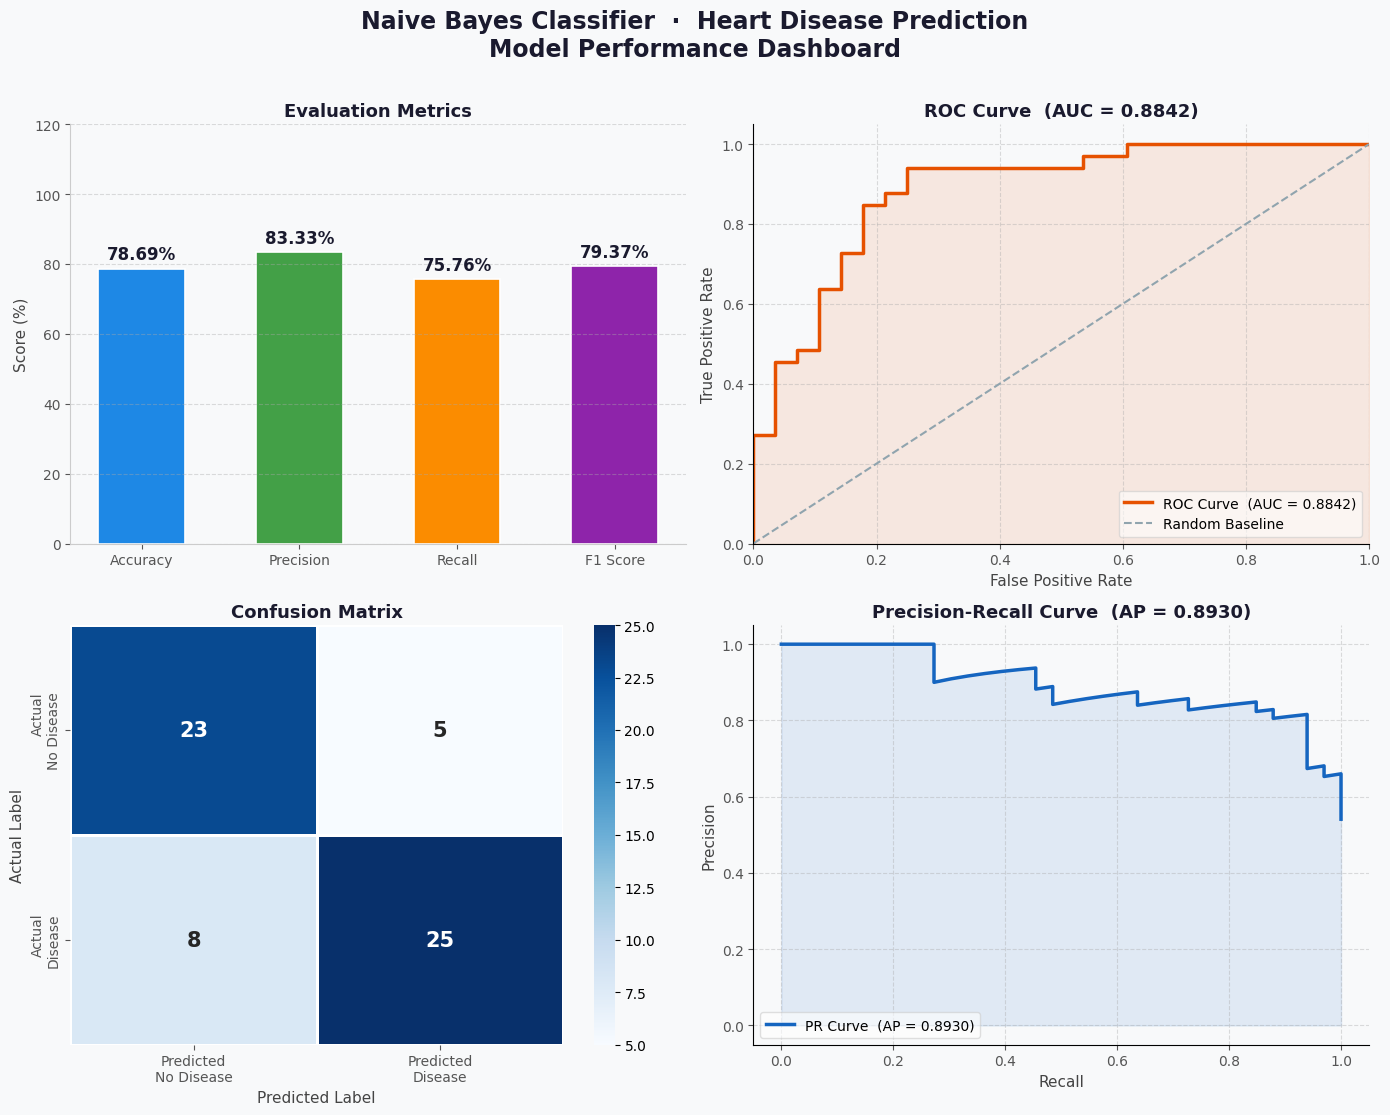

Figure 1 saved → naive_bayes_dashboard.png


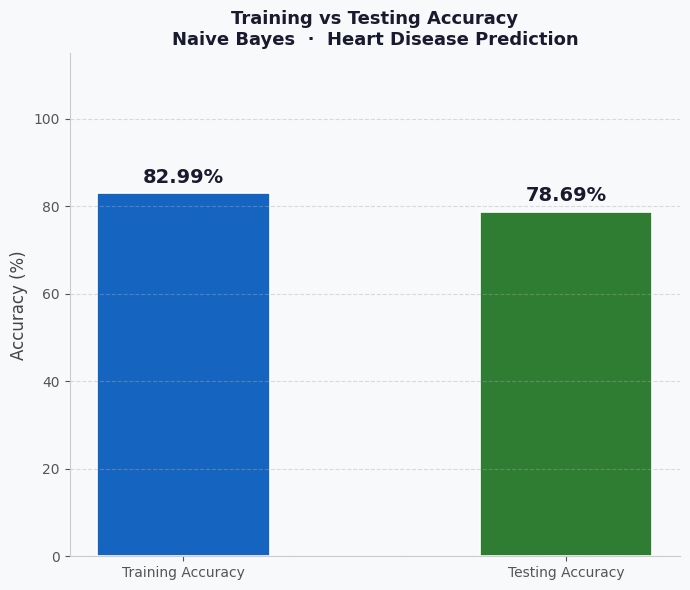

Figure 2 saved → train_vs_test_accuracy.png

✅ Both LinkedIn screenshots are ready in your project folder!


In [ ]:
# ==============================================================
# STEP 15: LINKEDIN-READY PERFORMANCE VISUALIZATIONS
# ==============================================================

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ── Predicted probabilities for positive class (needed for ROC & PR curves)
y_proba = model.predict_proba(X_test)[:, 1]

# ── ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = auc(fpr, tpr)

# ── Precision-Recall Curve
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
avg_precision           = average_precision_score(y_test, y_proba)

# ── Confusion Matrix (already computed in Step 11, reused here)
cm = confusion_matrix(y_test, y_pred)


# ==============================================================
# FIGURE 1: 4-IN-1 PERFORMANCE DASHBOARD
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor('#F8F9FA')

fig.suptitle(
    "Naive Bayes Classifier  ·  Heart Disease Prediction\n"
    "Model Performance Dashboard",
    fontsize=17, fontweight='bold', y=1.01, color='#1A1A2E'
)

# ─────────────────────────────────────────
# PLOT 1 (top-left): Evaluation Metrics Bar Chart
# ─────────────────────────────────────────
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]
bar_colors     = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

bars = axes[0, 0].bar(
    metrics_names, metrics_values,
    color=bar_colors, edgecolor='white',
    linewidth=1.2, width=0.55
)
axes[0, 0].set_ylim(0, 120)
axes[0, 0].set_facecolor('#F8F9FA')
axes[0, 0].set_title("Evaluation Metrics", fontsize=13, fontweight='bold', color='#1A1A2E')
axes[0, 0].set_ylabel("Score (%)", fontsize=11, color='#444')
axes[0, 0].tick_params(colors='#555')

for bar, val in zip(bars, metrics_values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#1A1A2E'
    )

axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4, color='#aaa')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].spines['left'].set_color('#ccc')
axes[0, 0].spines['bottom'].set_color('#ccc')

# ─────────────────────────────────────────
# PLOT 2 (top-right): ROC Curve
# ─────────────────────────────────────────
axes[0, 1].plot(
    fpr, tpr,
    color='#E65100', lw=2.5,
    label=f'ROC Curve  (AUC = {roc_auc:.4f})'
)
axes[0, 1].plot([0, 1], [0, 1], color='#90A4AE', lw=1.5,
                linestyle='--', label='Random Baseline')
axes[0, 1].fill_between(fpr, tpr, alpha=0.10, color='#E65100')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_facecolor('#F8F9FA')
axes[0, 1].set_xlabel("False Positive Rate", fontsize=11, color='#444')
axes[0, 1].set_ylabel("True Positive Rate", fontsize=11, color='#444')
axes[0, 1].set_title(f"ROC Curve  (AUC = {roc_auc:.4f})",
                      fontsize=13, fontweight='bold', color='#1A1A2E')
axes[0, 1].legend(loc='lower right', fontsize=10, framealpha=0.6)
axes[0, 1].grid(linestyle='--', alpha=0.4, color='#aaa')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].tick_params(colors='#555')

# ─────────────────────────────────────────
# PLOT 3 (bottom-left): Confusion Matrix
# ─────────────────────────────────────────
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues', ax=axes[1, 0],
    xticklabels=['Predicted\nNo Disease', 'Predicted\nDisease'],
    yticklabels=['Actual\nNo Disease', 'Actual\nDisease'],
    linewidths=2, linecolor='white',
    annot_kws={'size': 15, 'weight': 'bold'}
)
axes[1, 0].set_title("Confusion Matrix", fontsize=13, fontweight='bold', color='#1A1A2E')
axes[1, 0].set_ylabel("Actual Label", fontsize=11, color='#444')
axes[1, 0].set_xlabel("Predicted Label", fontsize=11, color='#444')
axes[1, 0].tick_params(colors='#555')

# ─────────────────────────────────────────
# PLOT 4 (bottom-right): Precision-Recall Curve
# ─────────────────────────────────────────
axes[1, 1].plot(
    rec_vals, prec_vals,
    color='#1565C0', lw=2.5,
    label=f'PR Curve  (AP = {avg_precision:.4f})'
)
axes[1, 1].fill_between(rec_vals, prec_vals, alpha=0.10, color='#1565C0')
axes[1, 1].set_facecolor('#F8F9FA')
axes[1, 1].set_xlabel("Recall", fontsize=11, color='#444')
axes[1, 1].set_ylabel("Precision", fontsize=11, color='#444')
axes[1, 1].set_title(f"Precision-Recall Curve  (AP = {avg_precision:.4f})",
                      fontsize=13, fontweight='bold', color='#1A1A2E')
axes[1, 1].legend(loc='lower left', fontsize=10, framealpha=0.6)
axes[1, 1].grid(linestyle='--', alpha=0.4, color='#aaa')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].tick_params(colors='#555')

plt.tight_layout()
plt.savefig("naive_bayes_dashboard.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 1 saved → naive_bayes_dashboard.png")


# ==============================================================
# FIGURE 2: TRAINING vs TESTING ACCURACY
# ==============================================================

fig2, ax2 = plt.subplots(figsize=(7, 6))
fig2.patch.set_facecolor('#F8F9FA')
ax2.set_facecolor('#F8F9FA')

categories = ['Training Accuracy', 'Testing Accuracy']
values     = [train_accuracy * 100, accuracy * 100]
bar_cols   = ['#1565C0', '#2E7D32']

bars2 = ax2.bar(
    categories, values,
    color=bar_cols, edgecolor='white',
    linewidth=1.2, width=0.45
)
ax2.set_ylim(0, 115)
ax2.set_title(
    "Training vs Testing Accuracy\n"
    "Naive Bayes  ·  Heart Disease Prediction",
    fontsize=13, fontweight='bold', color='#1A1A2E'
)
ax2.set_ylabel("Accuracy (%)", fontsize=12, color='#444')

for bar, val in zip(bars2, values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#1A1A2E'
    )

ax2.grid(axis='y', linestyle='--', alpha=0.4, color='#aaa')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#ccc')
ax2.spines['bottom'].set_color('#ccc')
ax2.tick_params(colors='#555')

plt.tight_layout()
plt.savefig("train_vs_test_accuracy.png", dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print("Figure 2 saved → train_vs_test_accuracy.png")

print("\n✅ Both LinkedIn screenshots are ready in your project folder!")